# Benchmarking perturbation-response prediction on Kang et al. 2018

[Kang et al. 2018](https://doi.org/10.1038/nbt.4042) profiled PBMCs from 8 patients, each split into an unstimulated control and an IFN-&beta;-stimulated culture, across 8 annotated cell types. It's the dataset both `scGen`'s own tutorials and `pertpy`'s `Scgen` docstring example use for their canonical perturbation-prediction task: hold out one cell type's stimulated profile entirely, and predict it from that cell type's own control state plus every other cell type's IFN-&beta; response.

This notebook runs that task end-to-end with two real predictors — [scGen](https://doi.org/10.1038/s41592-019-0494-8) (`pertpy`'s `Scgen`) and plain [`scvi.model.SCVI`](https://docs.scvi-tools.org/), predicting the counterfactual condition via its own `transform_batch` mechanism (see scvi-tools' "Counterfactual prediction" background page) instead of a dedicated shift-learning architecture — and asks whether either beats a naive floor, using [`scib_metrics.perturbation`](https://scib-metrics.readthedocs.io/) for the prediction task. [MrVI](https://openreview.net/forum?id=WsxleP2VBd) (`scvi.external.MRVI`) also appears, not as a third predictor but to ask a complementary question with the standard `scib_metrics.benchmark.Benchmarker`: whichever embedding predicts best, is it also a well-integrated one?

```{note}
Running the following cell will install tutorial dependencies on Google Colab only. It will have no effect on environments other than Google Colab.
```

In [1]:
!pip install --quiet scvi-colab
from scvi_colab import install

install()


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi_colab/_core.py:46: UserWarning: 
                Not currently in Google Colab environment.

                Please run with `run_outside_colab=True` to override.

                Returning with no further action.
                
  warn(


`scib_metrics.perturbation` depends on `pertpy`, which is not installed by default alongside `scvi-tools`. Install it with the `perturbation` extra.

In [2]:
%pip install --quiet "scib-metrics[perturbation]"


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Imports

In [ ]:
import os
import warnings
from importlib.metadata import version

warnings.filterwarnings("ignore")

import anndata as ad

# `pertpy` unconditionally flips JAX's global float precision to 64-bit at import time
# (`pertpy.tools._coda._sccoda` calls `jax.config.update("jax_enable_x64", True)` as a side effect
# of import). That silently breaks scib-metrics' own JAX-based kmeans/lisi code later in this
# notebook (`jax.lax.while_loop` carries float32 state and errors on a dtype mismatch once x64 is
# on). Restore the default (32-bit) precision explicitly right after importing pertpy.
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pertpy as pt
import scanpy as sc
import scib_metrics
import scvi
import seaborn as sns
from scib_metrics.benchmark import BatchCorrection, Benchmarker, BioConservation
from scib_metrics.perturbation import (
    PerturbationBaselines,
    PerturbationBenchmarker,
    PerturbationMetrics,
    delta_correlation,
)
from scipy.stats import pearsonr
from scvi.external import MRVI
from scvi.model import SCVI
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

jax.config.update("jax_enable_x64", False)

try:
    import rapids_singlecell as rsc

    HAS_RAPIDS = True
except Exception:
    HAS_RAPIDS = False

print(
    "Using rapids_singlecell for UMAPs:"
    if HAS_RAPIDS
    else "rapids_singlecell unavailable, falling back to scanpy for UMAPs:",
    HAS_RAPIDS,
)

In [3]:
# Helper Functions
def compute_neighbors_umap(adata, use_rep, n_neighbors=20, min_dist=0.3):
    """Neighbors + UMAP, GPU-accelerated via rapids_singlecell when available."""
    if HAS_RAPIDS:
        rsc.pp.neighbors(adata, use_rep=use_rep, n_neighbors=n_neighbors)
        rsc.tl.umap(adata, min_dist=min_dist)
    else:
        sc.pp.neighbors(adata, use_rep=use_rep, n_neighbors=n_neighbors)
        sc.tl.umap(adata, min_dist=min_dist)


def compute_pca_neighbors_umap(adata, n_comps=30, n_neighbors=20, min_dist=0.3):
    """PCA + neighbors + UMAP, for the unintegrated baseline embedding."""
    if HAS_RAPIDS:
        rsc.tl.pca(adata, n_comps=n_comps)
        rsc.pp.neighbors(adata, n_pcs=n_comps, n_neighbors=n_neighbors)
        rsc.tl.umap(adata, min_dist=min_dist)
    else:
        sc.pp.pca(adata, n_comps=n_comps)
        sc.pp.neighbors(adata, n_pcs=n_comps, n_neighbors=n_neighbors)
        sc.tl.umap(adata, min_dist=min_dist)


def to_dense_row(x):
    """Anndata slices can return sparse or dense; normalize to a flat 1D numpy array."""
    return np.asarray(x.toarray() if hasattr(x, "toarray") else x).ravel()


def reg_mean_plot_panel(ax, pred_mean, real_mean, gene_names, highlight_genes, title):
    """A log-scale mean/mean scatter with a regression line, R^2, and a few labeled genes —
    the same idea as scGen's own `reg_mean_plot`, just log-scaled (for readability across genes
    spanning several orders of magnitude) and usable inside a shared multi-panel figure.
    """
    # scGen's decoder is a plain Gaussian, not a non-negative count model — it can predict small
    # negative "expression" for near-zero genes, which `log1p` turns into NaN. Clip before logging.
    x = np.log1p(np.clip(pred_mean, 0, None))
    y = np.log1p(np.clip(real_mean, 0, None))
    r2 = pearsonr(x, y)[0] ** 2

    ax.scatter(x, y, s=8, alpha=0.4)
    coeffs = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.polyval(coeffs, xs), color="black", linewidth=1)

    gene_to_idx = {g: i for i, g in enumerate(gene_names)}
    for gene in highlight_genes:
        i = gene_to_idx[gene]
        ax.annotate(gene, (x[i], y[i]), fontsize=8, xytext=(3, 3), textcoords="offset points")
        ax.scatter([x[i]], [y[i]], s=20, color="red")

    ax.text(0.05, 0.9, f"$R^2$={r2:.2f}", transform=ax.transAxes)
    ax.set_xlabel("log1p(predicted)")
    ax.set_ylabel("log1p(ground truth)")
    ax.set_title(title)
    return r2

rapids_singlecell unavailable, falling back to scanpy for UMAPs: False


In [4]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with pertpy version:", version("pertpy"))
print("Last run with scib-metrics version:", scib_metrics.__version__)

Seed set to 0


Last run with scvi-tools version: 1.5.0.post1
Last run with pertpy version: 1.2.0
Last run with scib-metrics version: 0.6.0


Each model below is saved after training. Re-running this notebook top to bottom always retrains from scratch (the point of a tutorial), but if you're iterating on the analysis *after* the models exist, `<Model>.load(SAVE_DIR + "/...", adata=...)` skips training entirely.

In [5]:
SAVE_DIR = "saved_models_kang2018"
os.makedirs(SAVE_DIR, exist_ok=True)

## Load the data: Kang et al. 2018 IFN-&beta; stimulation

8 real patients, both conditions each; 8 annotated PBMC cell types; a real technical batch covariate (`replicate`, patient identity).

In [6]:
adata = pt.dt.kang_2018()
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'
    layers: None (.X)

In [7]:
adata.obs[["label", "cell_type", "replicate"]].head()

,label,cell_type,replicate
index,,,
AAACATACATTTCC-1,ctrl,CD14+ Monocytes,patient_1016
AAACATACCAGAAA-1,ctrl,CD14+ Monocytes,patient_1256
AAACATACCATGCA-1,ctrl,CD4 T cells,patient_1488
AAACATACCTCGCT-1,ctrl,CD14+ Monocytes,patient_1256
AAACATACCTGGTA-1,ctrl,Dendritic cells,patient_1039


In [8]:
adata.obs.groupby(["cell_type", "label"]).size().unstack()

label,ctrl,stim
cell_type,,
CD4 T cells,5560,5678
CD14+ Monocytes,2932,2765
B cells,1316,1335
NK cells,855,861
CD8 T cells,811,810
FCGR3A+ Monocytes,520,569
Dendritic cells,258,271
Megakaryocytes,63,69


### The classic scGen task: leave one cell type's stimulated profile out

Following [`pertpy`'s own `Scgen` tutorial](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/scgen_perturbation_prediction.html) exactly: hold out the *stimulated* cells of `CD4 T cells` only. Its *control* cells stay in training — the model needs to know what CD4 T cells look like at baseline, it just never sees what IFN-&beta; does to them.

In [9]:
held_out_celltypes = ["CD4 T cells"]

held_out_mask = adata.obs["cell_type"].isin(held_out_celltypes) & (adata.obs["label"] == "stim")
train = adata[~held_out_mask].copy()
test = adata[held_out_mask].copy()
train.shape, test.shape

((18995, 15706), (5678, 15706))

Restrict to a highly-variable-gene panel computed on the training set alone.

In [10]:
N_HVG_GENES = 2000

sc.pp.highly_variable_genes(train, n_top_genes=N_HVG_GENES, flavor="seurat_v3")
hvg_genes = train.var_names[train.var["highly_variable"]]
train = train[:, hvg_genes].copy()
test = test[:, hvg_genes].copy()
subset = adata[:, hvg_genes].copy()
train.shape, test.shape

((18995, 2000), (5678, 2000))

### Two models, two preprocessing conventions

`MrVI`, like `scVI`, models raw counts directly with a negative-binomial decoder — `train`/`subset` above, untouched, are exactly what it needs. `scGen`'s decoder is a fixed-variance Gaussian (`dist.Normal(generative_outputs["px"], 1)` in `pertpy`'s own `_scgenvae.py`) — a linear, MSE-style reconstruction that assumes library-size-normalized input, not raw counts. This matches the real `pertpy` tutorial exactly: it calls `sc.pp.normalize_total()` (no `log1p`) before `setup_anndata`. We build a separate normalized copy for every scGen-related step below — training, prediction, the real comparison cells, and the naive floor — while `MrVI` keeps training on the untouched raw counts.

In [11]:
TARGET_SUM = 1e4

train_scgen = train.copy()
sc.pp.normalize_total(train_scgen, target_sum=TARGET_SUM)

subset_norm = subset.copy()
sc.pp.normalize_total(subset_norm, target_sum=TARGET_SUM)

```{note}
**Why not the same `PerturbationBenchmarker` baseline machinery used for CRISPR-combination tasks?** `MeanBaseline`/`AdditiveBaseline`/`LinearBaseline` all fit relative to *one shared reference profile*, appropriate when every perturbation is measured against the same control population (e.g. one cell line). Kang's `control` state is different for every cell type — a monocyte's resting profile has nothing to do with a T cell's — so pooling all cell types' controls into one shared reference would conflate cell-type identity with the stimulation effect we actually want to measure. We instead use the `delta_correlation` metric directly (a plain correlation function, no shared-reference assumption) and compute two naive floors by hand, matched to this task's actual per-cell-type structure.
```

## scGen: leave-cell-type-out prediction

Exactly the canonical setup: `batch_key` is the condition (`label`), `labels_key` is the cell type. scGen learns one global IFN-&beta; shift in latent space from the cell types it *does* see both conditions of, then applies that shift to the held-out cell type's own control cells.

In [12]:
pt.tl.Scgen.setup_anndata(train_scgen, batch_key="label", labels_key="cell_type")
scgen_model = pt.tl.Scgen(train_scgen, n_hidden=256, n_latent=30)
scgen_model.train(max_epochs=150, batch_size=128, early_stopping=True, early_stopping_patience=10)
scgen_model.save(os.path.join(SAVE_DIR, "scgen"), overwrite=True)

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda13.initialize()
Traceback (most recent call last):
  File "/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 495, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/jax_plugins/xla_cuda13/__init__.py", line 373, in initialize
    c_api = xb.register_plugin(
        'cuda', priority=500, library_path=str(path), options=options
    )
  File "/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 637, in register_plugin
    c_api = xla_client.load_pjrt_plugin_dynamically(plugin_name, library_path)
  File "/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/jaxlib/xla_client.py", line 115, in load_pjrt_plugin_dynamically
    return _xla.load_pjrt_plugin(plugin_name, library_path, c_api=None)
           ~~~~~~

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


GPU available: True (cuda), used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/150 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=150` reached.


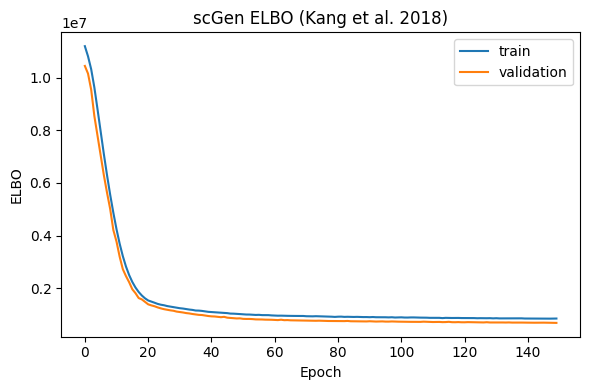

In [13]:
hist = scgen_model.history
if "elbo_train" in hist:
    plt.figure(figsize=(6, 4))
    plt.plot(hist["elbo_train"], label="train")
    if "elbo_validation" in hist:
        plt.plot(hist["elbo_validation"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("ELBO")
    plt.title("scGen ELBO (Kang et al. 2018)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Visualizing the scGen latent space

scGen's `batch_key` during training was the *condition* (`label`), not patient identity — so the panel below colored by `replicate` is checking something scGen was never asked to correct for, purely out of curiosity about what it does incidentally. `cell_type` separation, by contrast, is a direct check of what `labels_key` should preserve.

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


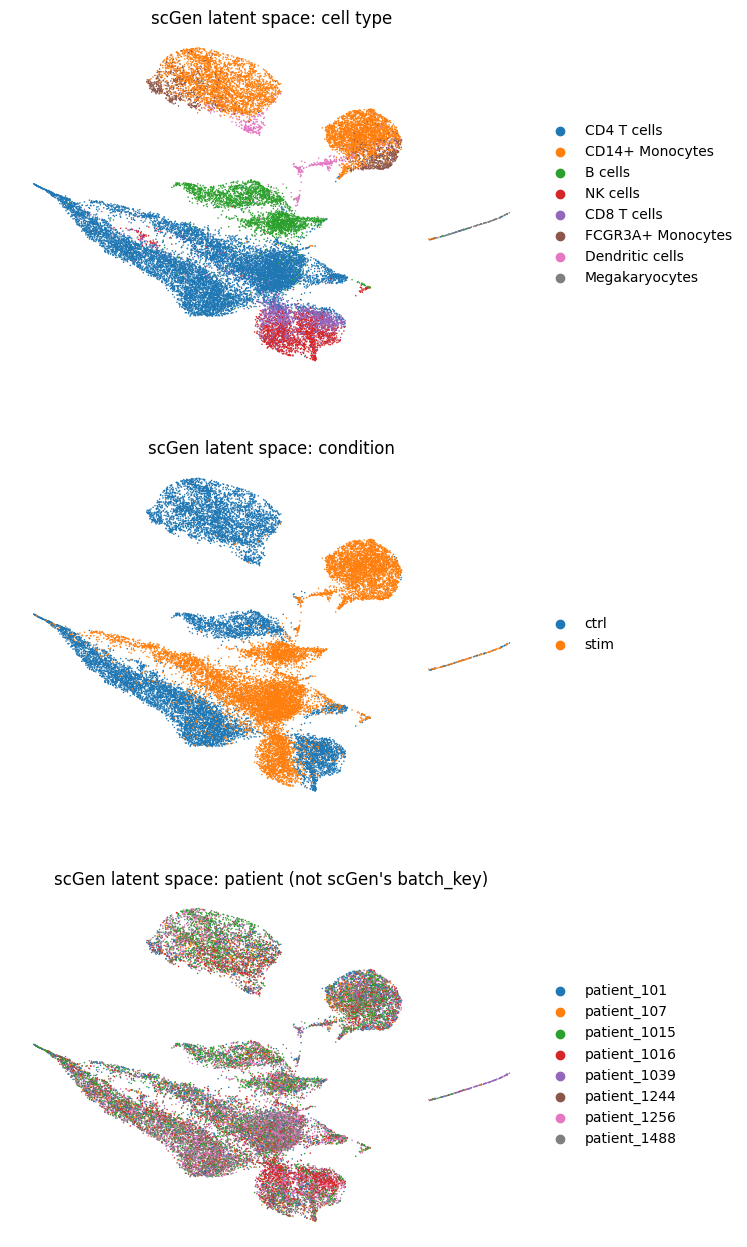

In [14]:
scgen_latent = subset_norm.copy()
scgen_latent.obsm["X_scGen"] = scgen_model.get_latent_representation(scgen_latent)
compute_neighbors_umap(scgen_latent, use_rep="X_scGen")
sc.pl.umap(
    scgen_latent,
    color=["cell_type", "label", "replicate"],
    frameon=False,
    ncols=1,
    title=[
        "scGen latent space: cell type",
        "scGen latent space: condition",
        "scGen latent space: patient (not scGen's batch_key)",
    ],
)

### Predicting the held-out cell type

`scg.predict()` returns the predicted stimulated profile for the held-out cell type's own control cells. We evaluate it exactly as `pertpy`'s own tutorial does: build a comparison `AnnData` of the real control, real stimulated, and predicted cells, and use `plot_reg_mean_plot` — a scatter of predicted vs. real mean expression per gene, reporting R² for all genes and for the top-100 differentially-expressed genes.

INFO     Received view of anndata, making copy.                                                                    


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Received view of anndata, making copy.                                                                    


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Received view of anndata, making copy.                                                                    


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


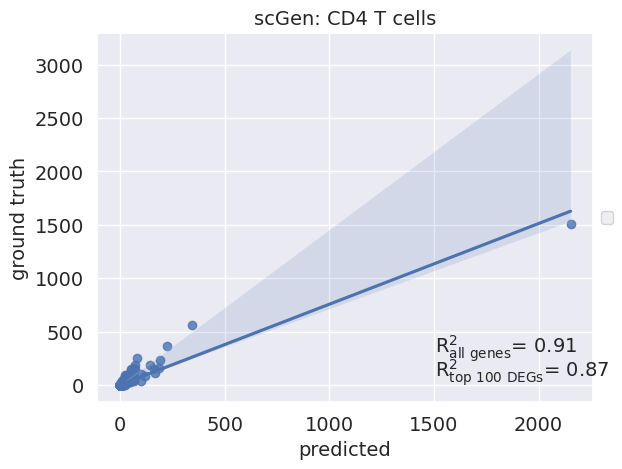

R^2 (all genes): {'CD4 T cells': np.float64(0.9052888646669153)}
R^2 (top 100 DE genes): {'CD4 T cells': np.float64(0.8678857183549312)}


In [15]:
scgen_predicted_deltas = {}
scgen_predicted_stim_means = {}
scgen_real_stim_means = {}
scgen_r2_all = {}
scgen_r2_top100 = {}
top_100_genes_by_celltype = {}

for cell_type in held_out_celltypes:
    pred, _ = scgen_model.predict(ctrl_key="ctrl", stim_key="stim", celltype_to_predict=cell_type)
    pred.obs["label"] = "pred"

    real_cells = subset_norm[(subset_norm.obs["cell_type"] == cell_type)].copy()
    eval_adata = ad.concat([real_cells, pred], join="outer")
    eval_adata.obs["cell_type"] = cell_type

    # Rank DE genes on a separately log-transformed copy — `real_cells.X` itself stays on the
    # library-size-normalized (not logged) scale scGen was trained on and predicts on.
    de_input = real_cells.copy()
    sc.pp.log1p(de_input)
    sc.tl.rank_genes_groups(
        de_input, groupby="label", groups=["stim"], reference="ctrl", method="wilcoxon"
    )
    top_100_genes = de_input.uns["rank_genes_groups"]["names"]["stim"][:100].tolist()
    top_100_genes_by_celltype[cell_type] = top_100_genes

    r2_all, r2_top100 = scgen_model.plot_reg_mean_plot(
        eval_adata,
        condition_key="label",
        axis_keys={"x": "pred", "y": "stim"},
        labels={"x": "predicted", "y": "ground truth"},
        top_100_genes=top_100_genes,
        title=f"scGen: {cell_type}",
        show=True,
    )
    scgen_r2_all[cell_type] = r2_all
    scgen_r2_top100[cell_type] = r2_top100

    pred_mean = to_dense_row(pred.X.mean(axis=0))
    ctrl_mean = to_dense_row(real_cells[real_cells.obs["label"] == "ctrl"].X.mean(axis=0))
    stim_mean = to_dense_row(real_cells[real_cells.obs["label"] == "stim"].X.mean(axis=0))
    scgen_predicted_deltas[cell_type] = pred_mean - ctrl_mean
    scgen_predicted_stim_means[cell_type] = pred_mean
    scgen_real_stim_means[cell_type] = stim_mean

print("R^2 (all genes):", scgen_r2_all)
print("R^2 (top 100 DE genes):", scgen_r2_top100)

### A gene-level view: the top IFN-&beta;-response gene

The top differentially-expressed gene for the held-out cell type, shown as a violin across real control, real stimulated, and predicted cells.

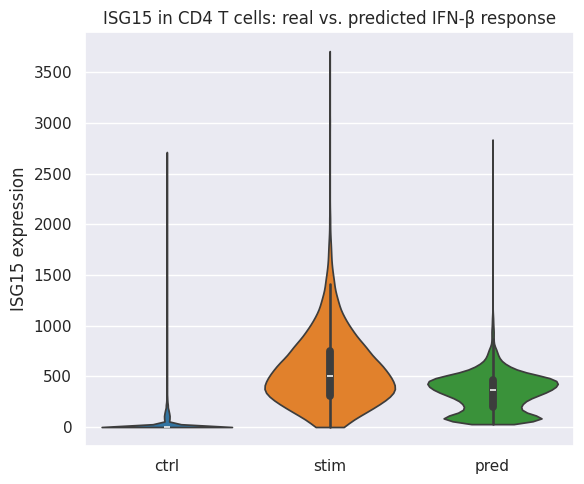

In [16]:
top_gene = top_100_genes_by_celltype[held_out_celltypes[0]][0]
violin_df = pd.DataFrame(
    {
        "expression": to_dense_row(eval_adata[:, top_gene].X),
        "group": pd.Categorical(
            eval_adata.obs["label"].astype(str), categories=["ctrl", "stim", "pred"], ordered=True
        ),
    }
)
fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(data=violin_df, x="group", y="expression", palette="tab10", cut=0, ax=ax)
ax.set_title(f"{top_gene} in {held_out_celltypes[0]}: real vs. predicted IFN-\u03b2 response")
ax.set_xlabel("")
ax.set_ylabel(f"{top_gene} expression")
plt.tight_layout()
plt.show()

## MrVI: a well-integrated embedding, set aside as a predictor

Kang's 8 patients give MrVI a genuine multi-sample axis, with a real technical nuisance covariate (`replicate`) as `batch_key` — unlike a purely combinatorial-genetics dataset with no natural donor structure. We still set `sample_key="label"` so MrVI's `u` is explicitly asked to be invariant to condition as well as to nuisance batch effects. `labels_key="cell_type"` uses real annotations.

We only use MrVI for its embedding here — the standard bio-conservation/batch-correction benchmark below — not as a third predictor. Its own counterfactual mechanism is a genuine, native part of the model (see scvi-tools' MrVI user guide page), but repurposing a two-category `sample_key` for a task it wasn't built around added a lot of caveats for a result that came out indistinguishable from the naive floor. The next section's `SCVI` comparison asks the more useful counterfactual-prediction question with a model whose `transform_batch` mechanism is designed for exactly this.

```{note}
**scGen's and MrVI's `batch_key` are deliberately different, and that matters for the standard benchmark below.** scGen's `batch_key` is the *condition* (`label`) — it has no separate slot for patient identity. MrVI's `batch_key` is `replicate` — the actual nuisance covariate. When the standard scib-metrics benchmark later scores embeddings against `batch_key="replicate"`, it's asking a question scGen (and, below, `SCVI`) were never trained to answer; MrVI was. Keep that in mind when reading those results — a low score there for scGen or `SCVI` isn't a modeling failure, and a low score for MrVI *would* be a real one, since patient-batch removal is exactly what it was set up to do.
```

In [17]:
MRVI.setup_anndata(
    train,
    sample_key="label",
    batch_key="replicate",
    labels_key="cell_type",
)
mrvi_model = MRVI(train)
mrvi_model.train(
    max_epochs=150, accelerator="gpu", early_stopping=True, early_stopping_patience=10
)
mrvi_model.save(os.path.join(SAVE_DIR, "mrvi"), overwrite=True)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/150 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 4676.837. Signaling Trainer to stop.


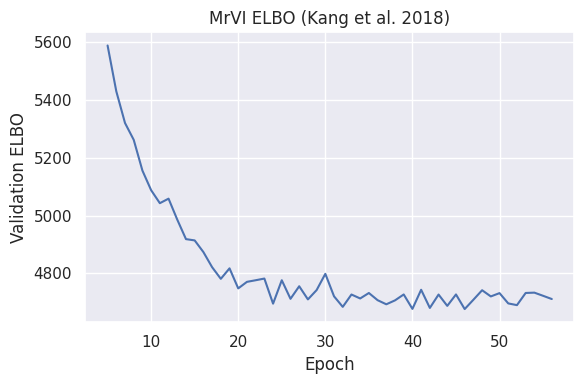

In [18]:
mrvi_hist = mrvi_model.history
if "elbo_validation" in mrvi_hist:
    plt.figure(figsize=(6, 4))
    plt.plot(mrvi_hist["elbo_validation"].iloc[5:])
    plt.xlabel("Epoch")
    plt.ylabel("Validation ELBO")
    plt.title("MrVI ELBO (Kang et al. 2018)")
    plt.tight_layout()
    plt.show()

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


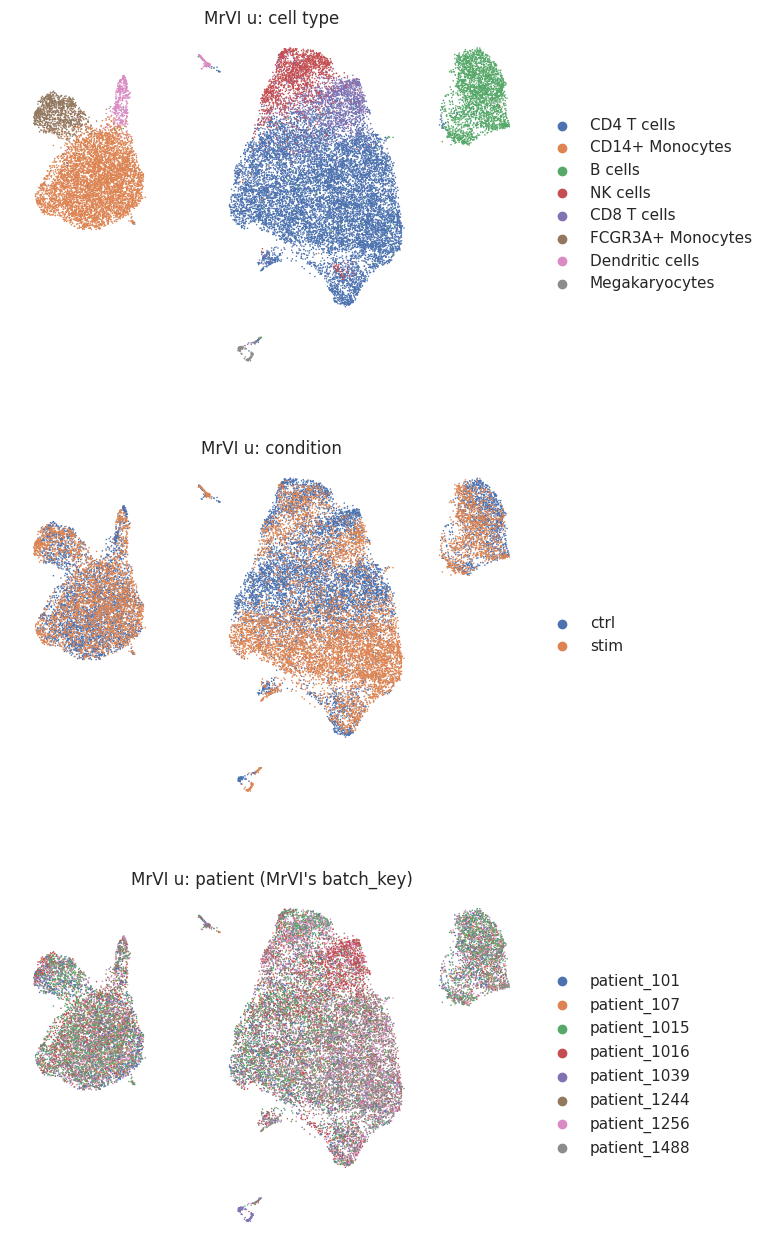

In [19]:
mrvi_latent = subset.copy()
mrvi_latent.obs["_indices"] = np.arange(mrvi_latent.n_obs).astype(int)
mrvi_latent.obsm["X_mrVI_u"] = mrvi_model.get_latent_representation(mrvi_latent)
compute_neighbors_umap(mrvi_latent, use_rep="X_mrVI_u")
sc.pl.umap(
    mrvi_latent,
    color=["cell_type", "label", "replicate"],
    frameon=False,
    ncols=1,
    title=["MrVI u: cell type", "MrVI u: condition", "MrVI u: patient (MrVI's batch_key)"],
)

## scVI: a plain counterfactual baseline via `transform_batch`

`scGen` is a dedicated shift-learning architecture. Does that specialization actually buy anything over the simplest thing scvi-tools already offers out of the box? A standard `scvi.model.SCVI` trained with `batch_key="label"` learns a generic conditional decoder — no explicit latent-shift mechanism — and `get_normalized_expression(..., transform_batch="stim")` asks it to decode a cell's own latent state as if it belonged to the other batch. This is exactly the counterfactual mechanism described in scvi-tools' "Counterfactual prediction" background page, applied here to the same leave-cell-type-out task as scGen — a fair, public-API-only comparison (no module-internal calls needed for this one).

In [20]:
SCVI.setup_anndata(train, batch_key="label")
scvi_model = SCVI(train, n_hidden=256, n_latent=30)
scvi_model.train(max_epochs=150, batch_size=128, early_stopping=True, early_stopping_patience=10)
scvi_model.save(os.path.join(SAVE_DIR, "scvi"), overwrite=True)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/150 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=150` reached.


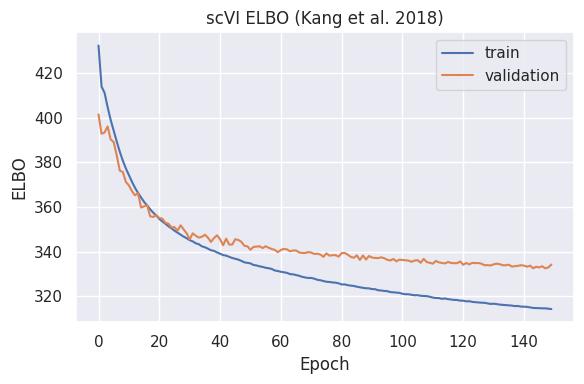

In [21]:
scvi_hist = scvi_model.history
if "elbo_train" in scvi_hist:
    plt.figure(figsize=(6, 4))
    plt.plot(scvi_hist["elbo_train"], label="train")
    if "elbo_validation" in scvi_hist:
        plt.plot(scvi_hist["elbo_validation"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("ELBO")
    plt.title("scVI ELBO (Kang et al. 2018)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Same caveat as scGen above: `batch_key="label"` here too, not `replicate`.

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


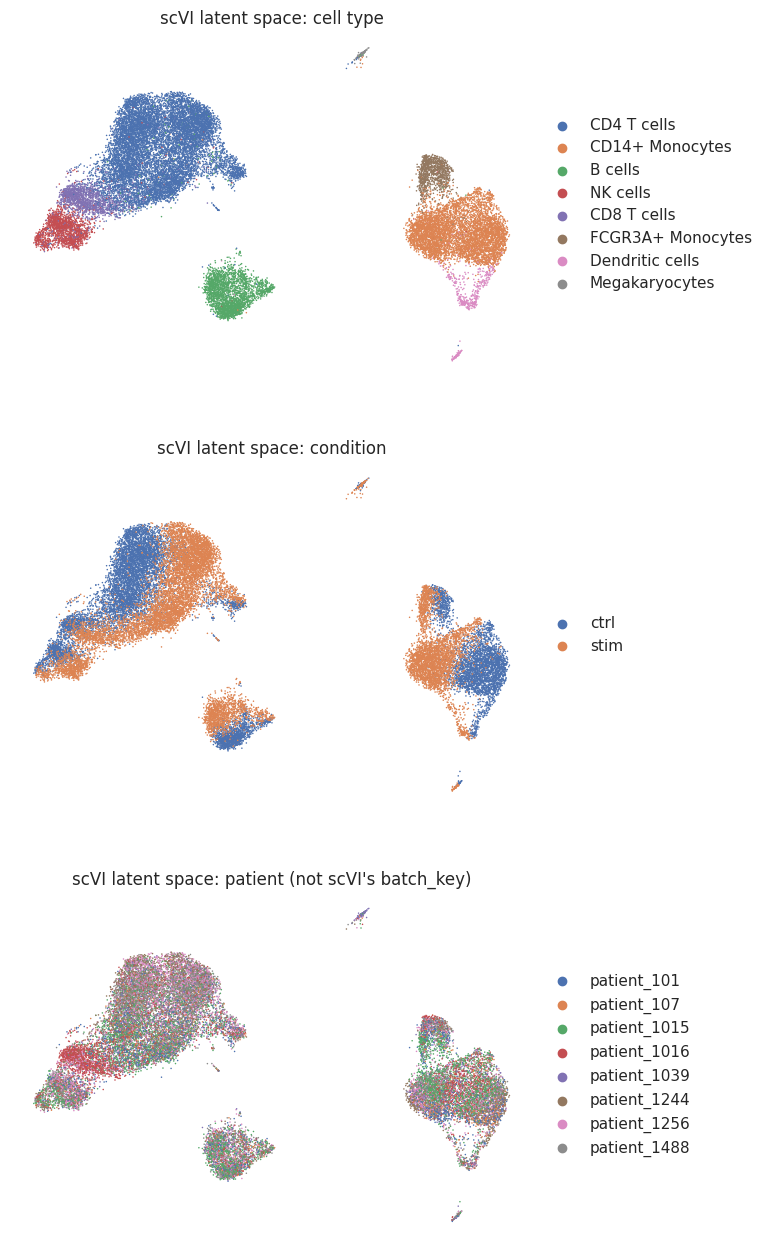

In [22]:
scvi_latent = subset.copy()
scvi_latent.obsm["X_scVI"] = scvi_model.get_latent_representation(scvi_latent)
compute_neighbors_umap(scvi_latent, use_rep="X_scVI")
sc.pl.umap(
    scvi_latent,
    color=["cell_type", "label", "replicate"],
    frameon=False,
    ncols=1,
    title=[
        "scVI latent space: cell type",
        "scVI latent space: condition",
        "scVI latent space: patient (not scVI's batch_key)",
    ],
)

Predicting the held-out cell type: ask `get_normalized_expression` for both the real (`"ctrl"`) and counterfactual (`"stim"`) batch on the held-out cell type's control cells, both with `library_size=TARGET_SUM` so they land on the exact same scale as scGen's normalized predictions — decoding both sides through the model (rather than comparing against the real raw counts on one side) keeps the delta attributable purely to the batch swap.

In [23]:
scvi_predicted_deltas = {}
scvi_predicted_stim_means = {}
for cell_type in held_out_celltypes:
    ctrl_cells = train[(train.obs["cell_type"] == cell_type) & (train.obs["label"] == "ctrl")]
    # Decode both sides through the model on the same `library_size`-normalized scale — comparing
    # the counterfactual "stim" decode against the *real* raw-count `ctrl_cells.X` mean would mix
    # two different scales into the delta and swamp any genuine signal.
    ctrl_pred_mean = scvi_model.get_normalized_expression(
        adata=ctrl_cells, transform_batch="ctrl", library_size=TARGET_SUM, return_numpy=True
    ).mean(axis=0)
    stim_pred_mean = scvi_model.get_normalized_expression(
        adata=ctrl_cells, transform_batch="stim", library_size=TARGET_SUM, return_numpy=True
    ).mean(axis=0)
    scvi_predicted_deltas[cell_type] = stim_pred_mean - ctrl_pred_mean
    scvi_predicted_stim_means[cell_type] = stim_pred_mean

{k: v.shape for k, v in scvi_predicted_deltas.items()}

INFO     Received view of anndata, making copy.                                                                    


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


{'CD4 T cells': (2000,)}

### Side by side: scGen vs. scVI mean matching

The same log-scale mean/mean view for both predictors, with a handful of the top differentially-expressed genes labeled — the same spirit as `pertpy`'s own `plot_reg_mean_plot`, in log scale and side by side for a direct comparison.

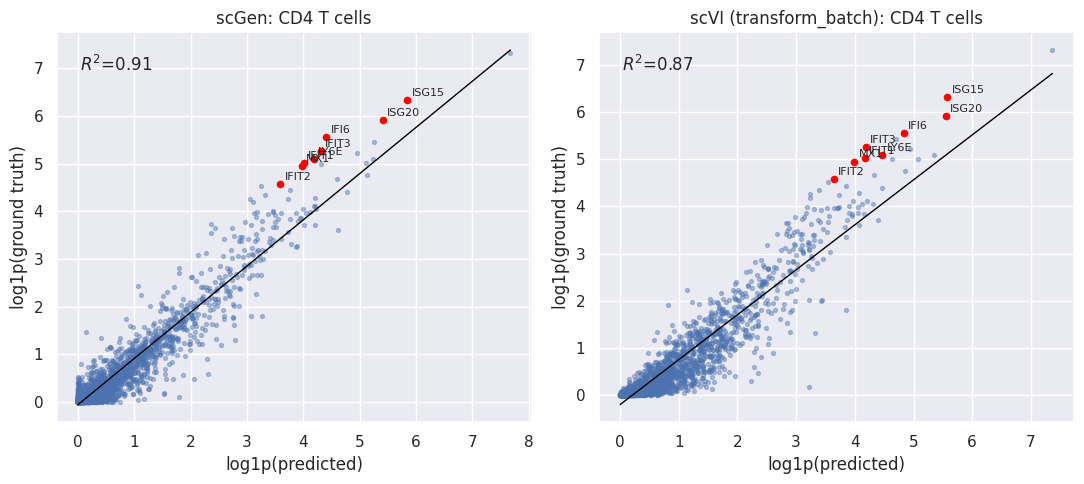

In [24]:
cell_type = held_out_celltypes[0]
highlight_genes = top_100_genes_by_celltype[cell_type][:8]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
reg_mean_plot_panel(
    axes[0],
    scgen_predicted_stim_means[cell_type],
    scgen_real_stim_means[cell_type],
    hvg_genes,
    highlight_genes,
    f"scGen: {cell_type}",
)
reg_mean_plot_panel(
    axes[1],
    scvi_predicted_stim_means[cell_type],
    scgen_real_stim_means[cell_type],
    hvg_genes,
    highlight_genes,
    f"scVI (transform_batch): {cell_type}",
)
plt.tight_layout()
plt.show()

## Head-to-head: naive floors vs. scGen vs. scVI

Two naive floors, both matched to this task's per-cell-type structure (not the shared-reference baselines used for combinatorial-genetics tasks):

- **mean (naive floor)** — the average control&rarr;stimulated shift across the cell types the models *did* see both conditions of, applied uniformly to the held-out cell type, blind to which one is asked for.
- **linear (profile-based)** — ridge regression from each trained cell type's own average control-expression profile (reduced to a few principal components) to its observed shift; predicts the held-out cell type's shift from *its* control profile's position in that same space. Unlike a one-hot cell-type encoding (which can't generalize to an unseen category at all), this lets cell types with similar resting profiles inform each other's predicted response.

In [25]:
trained_celltypes = [
    ct for ct in adata.obs["cell_type"].cat.categories if ct not in held_out_celltypes
]

ctrl_profiles, shifts = [], []
for cell_type in trained_celltypes:
    cells = train_scgen[train_scgen.obs["cell_type"] == cell_type]
    ctrl_mean = to_dense_row(cells[cells.obs["label"] == "ctrl"].X.mean(axis=0))
    stim_mean = to_dense_row(cells[cells.obs["label"] == "stim"].X.mean(axis=0))
    ctrl_profiles.append(ctrl_mean)
    shifts.append(stim_mean - ctrl_mean)
ctrl_profiles = np.stack(ctrl_profiles)
shifts = np.stack(shifts)

naive_shift = shifts.mean(axis=0)

pca = PCA(n_components=4, random_state=0).fit(ctrl_profiles)
ridge = Ridge(alpha=10.0).fit(pca.transform(ctrl_profiles), shifts)

linear_shifts = {}
for cell_type in held_out_celltypes:
    held_out_ctrl_profile = to_dense_row(
        subset_norm[
            (subset_norm.obs["cell_type"] == cell_type) & (subset_norm.obs["label"] == "ctrl")
        ].X.mean(axis=0)
    )
    linear_shifts[cell_type] = ridge.predict(pca.transform(held_out_ctrl_profile[None, :]))[0]

In [26]:
# `true_deltas`/naive floors/`scgen_deltas`/`scvi_deltas` all use the same library-size-normalized
# scale (`subset_norm`/`TARGET_SUM`) — no cross-scale approximation needed this time.
true_deltas, naive_deltas, linear_deltas, scgen_deltas, scvi_deltas = [], [], [], [], []
for cell_type in held_out_celltypes:
    real_cells = subset_norm[(subset_norm.obs["cell_type"] == cell_type)]
    ctrl_mean = to_dense_row(real_cells[real_cells.obs["label"] == "ctrl"].X.mean(axis=0))
    stim_mean = to_dense_row(real_cells[real_cells.obs["label"] == "stim"].X.mean(axis=0))
    true_deltas.append(stim_mean - ctrl_mean)
    naive_deltas.append(naive_shift)
    linear_deltas.append(linear_shifts[cell_type])
    scgen_deltas.append(scgen_predicted_deltas[cell_type])
    scvi_deltas.append(scvi_predicted_deltas[cell_type])

true_deltas = np.stack(true_deltas)
predictors = {
    "mean (naive floor)": np.stack(naive_deltas),
    "linear (profile-based)": np.stack(linear_deltas),
    "scgen": np.stack(scgen_deltas),
    "scvi": np.stack(scvi_deltas),
}
kang_results = pd.DataFrame(
    {
        name: delta_correlation(preds, true_deltas)["mean"] for name, preds in predictors.items()
    }.items(),
    columns=["predictor", "delta_correlation"],
).set_index("predictor")
kang_results

,delta_correlation
predictor,
mean (naive floor),0.960253
linear (profile-based),0.972919
scgen,0.981549
scvi,0.978641


### For comparison: the `PerturbationBenchmarker` class itself

The hand-rolled floors above exist because `PerturbationBenchmarker`'s built-in `MeanBaseline`/`AdditiveBaseline`/`LinearBaseline` fit relative to *one shared reference profile* — here, that means pooling `ctrl` cells across *all* cell types into a single reference, which conflates cell-type identity with the stimulation effect (see the note earlier in this notebook). With that caveat explicit, it's still worth showing the class itself in action with all three baselines enabled, exactly as the companion Norman 2019 tutorial does — same `predictions=` argument, same `train`/`test` split already built above, just with `target_col="label"` and `reference_key="ctrl"` instead of a `"+"`-combination-aware perturbation column.

All three baselines come out identical here (and match the *sign-flipped* naive floor from the hand-rolled comparison above): with only one non-reference category (`stim`) in this pooled framing, `AdditiveBaseline` has no `"+"`-combination to decompose (falls back to the mean shift), and `LinearBaseline`'s ridge regression has exactly one `(encoding, delta)` training pair to fit — both degenerate to the same single pooled-`ctrl`-vs-`stim` shift as `MeanBaseline`. That shift is a *worse* floor than either hand-rolled one (-0.01 vs. 0.96-0.97) precisely because of the reference-pooling issue flagged above — a concrete illustration of why this notebook computes its own floors instead.

In [51]:
benchmarker = PerturbationBenchmarker(
    train,
    test,
    target_col="label",
    reference_key="ctrl",
    perturbation_encodings={"stim": np.array([1.0])},
    predictions={
        "scgen": np.stack([scgen_predicted_deltas[ct] for ct in held_out_celltypes]),
        "scvi": np.stack([scvi_predicted_deltas[ct] for ct in held_out_celltypes]),
    },
    baselines=PerturbationBaselines(mean=True, additive=True, linear=True),
    metrics=PerturbationMetrics(combination_additivity=True),
)
benchmarker.benchmark()
benchmarker.get_results()

          is_baseline  delta_correlation
mean             True          -0.010951
additive         True          -0.010951
linear           True          -0.010951
scgen           False           0.859554
scvi            False           0.863889

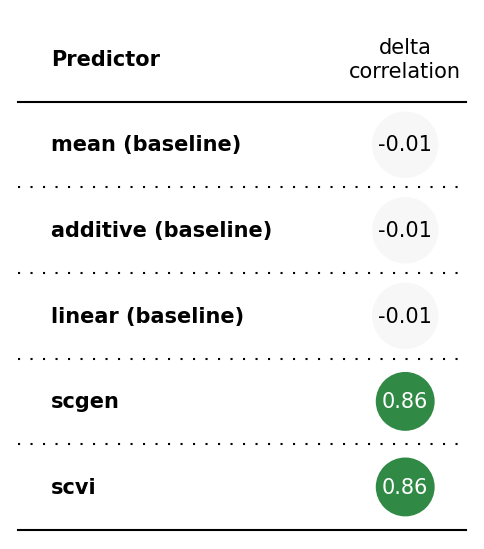

In [52]:
benchmarker.plot_results_table()

`combination_additivity` is enabled above too. It looks for `"+"`-separated perturbation names in `adata.obs_names` (the genetic-combination structure Norman 2019 has and Kang does not) — since `stim` has no `"+"` in it, the metric warns and returns an empty result rather than erroring. Showing it here for completeness: this is what "doesn't apply" looks like in practice, not silently skipped.

In [53]:
benchmarker.get_combination_additivity()

/home/access/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scib_metrics/perturbation/_metrics.py:112: UserWarning: No combination-named perturbations found in `adata.obs_names` (using separator '+'); returning an empty result.
  warnings.warn(


Empty DataFrame
Columns: [distance, predicted_magnitude, measured_magnitude]
Index: []

## The standard scib-metrics benchmark

`cell_type` as the biological label we want preserved, `replicate` (patient) as the technical batch we want removed. As noted above: this is exactly MrVI's own `batch_key`, but *not* what scGen's or scVI's `batch_key` (`label`, the condition) was trained against — keep that asymmetry in mind when comparing batch-correction scores below.

In [29]:
subset_log = subset_norm.copy()
sc.pp.log1p(subset_log)
compute_pca_neighbors_umap(subset_log, n_comps=30)

benchmark_adata = subset.copy()
benchmark_adata.obsm["Unintegrated"] = subset_log.obsm["X_pca"]
benchmark_adata.obsm["scGen"] = scgen_latent.obsm["X_scGen"]
benchmark_adata.obsm["MrVI_u"] = mrvi_latent.obsm["X_mrVI_u"]
benchmark_adata.obsm["scVI"] = scvi_latent.obsm["X_scVI"]

scib_benchmarker = Benchmarker(
    benchmark_adata,
    batch_key="replicate",
    label_key="cell_type",
    embedding_obsm_keys=["Unintegrated", "scGen", "MrVI_u", "scVI"],
    pre_integrated_embedding_obsm_key="X_pca",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    n_jobs=4,
)
scib_benchmarker.benchmark()
kang_scib_results = scib_benchmarker.get_results(min_max_scale=False)
kang_scib_results

Computing neighbors:   0%|          | 0/4 [00:00<?, ?it/s]

Computing neighbors:  25%|██▌       | 1/4 [00:03<00:09,  3.19s/it]

Computing neighbors:  50%|█████     | 2/4 [00:05<00:05,  2.77s/it]

Computing neighbors:  75%|███████▌  | 3/4 [00:07<00:02,  2.45s/it]

Computing neighbors: 100%|██████████| 4/4 [00:09<00:00,  2.36s/it]

...

Metrics:  73%|███████▎  | 8/11 [00:27<00:10,  3.60s/it, Batch correction: pcr_comparison]    

Metrics:  82%|████████▏ | 9/11 [00:27<00:05,  2.72s/it, Batch correction: pcr_comparison]

Embeddings: 100%|██████████| 4/4 [08:34<00:00, 87.10s/it] 

Embeddings: 100%|██████████| 4/4 [08:34<00:00, 128.66s/it]

,Isolated labels,KMeans NMI,KMeans ARI,Silhouette label,cLISI,BRAS,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total
Embedding,,,,,,,,,,,,,
Unintegrated,0.603254,0.656003,0.502715,0.550988,1.0,0.836566,0.40353,0.565459,0.857024,0.283826,0.589281,0.662592,0.633268
scGen,0.575611,0.294986,0.170064,0.500669,0.997744,0.82084,0.41141,0.547758,0.949836,0.324569,0.610882,0.507815,0.549042
MrVI_u,0.641796,0.635617,0.455635,0.598682,1.0,0.792116,0.430182,0.583177,0.947565,0.020901,0.554788,0.666346,0.621723
scVI,0.567191,0.617052,0.381791,0.53602,0.996888,0.864256,0.365042,0.414854,0.895068,0.294537,0.566751,0.619788,0.598574
Metric Type,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Batch correction,Batch correction,Batch correction,Batch correction,Batch correction,Aggregate score,Aggregate score,Aggregate score


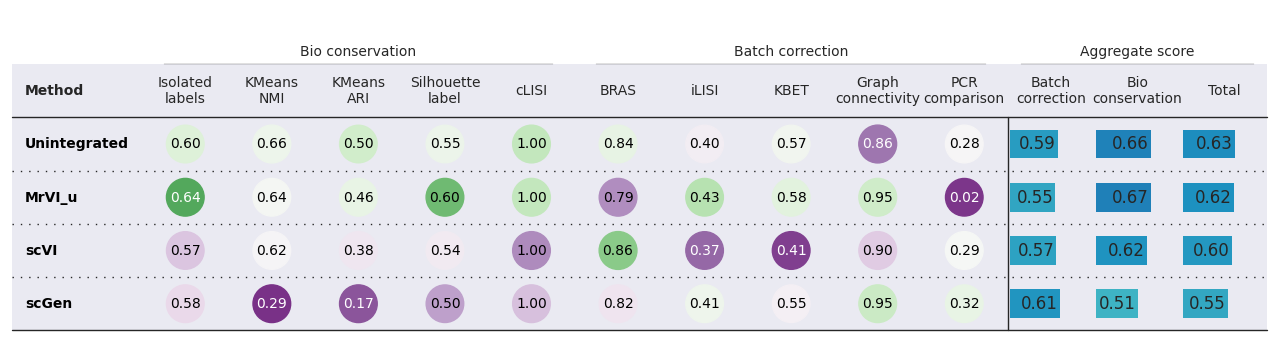

In [30]:
scib_benchmarker.plot_results_table(min_max_scale=False)

Read the batch-correction column in light of the asymmetry above, not as a like-for-like contest: `MrVI_u` was explicitly trained to remove `replicate` effects; `scGen`'s and `scVI`'s embeddings removing them (or not) is incidental to what they were actually optimized for, and `Unintegrated` was never asked to remove anything. If `Unintegrated` scores competitively here, that's also consistent with Kang's patient-to-patient variation simply being modest to begin with — not necessarily evidence that any model's batch-correction mechanism underperformed.

## Summary

- Two real predictors — `pertpy`'s scGen and a plain `scvi.model.SCVI` using its own `transform_batch` counterfactual mechanism — predict a held-out cell type's IFN-&beta; response, scored against two naive floors matched to Kang's per-cell-type structure (not the shared-reference baselines built for combinatorial-genetics tasks).
- `scGen` needs library-size-normalized input (its decoder is a fixed-variance Gaussian, not a count model) while `scVI` needs raw counts, matching MrVI — each gets its own correctly-preprocessed copy of the same underlying data.
- `scVI`'s counterfactual prediction uses only its public API (`get_normalized_expression` with `transform_batch`) — no module-internal calls needed, unlike the workaround MrVI's own counterfactual mechanism would have required for this same task.
- `MrVI` is deliberately kept out of the predictor comparison and used only for its embedding: with a real multi-donor `sample`/`batch` structure (`replicate` as `batch_key`), the standard `scib_metrics.benchmark.Benchmarker` asks a genuinely different, complementary question from the perturbation-prediction floor — is the embedding well-integrated? — and the three models' `batch_key`s during training are genuinely different, which matters for how to read that benchmark's batch-correction half.

### References

- Kang, H. M. et al. ["Multiplexed droplet single-cell RNA-sequencing using natural genetic variation."](https://doi.org/10.1038/nbt.4042) Nature Biotechnology 36, 89–94 (2018).
- Xu, C. et al. ["scGen predicts single-cell perturbation responses."](https://doi.org/10.1038/s41592-019-0494-8) Nature Methods 16, 715–721 (2019).
- `scVI` and `MrVI` are already fully cited in scvi-tools' own user guide — see the links in this notebook's introduction above.
- [`pertpy` scGen perturbation-prediction tutorial](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/scgen_perturbation_prediction.html)
- [`scib_metrics.perturbation` API reference](https://scib-metrics.readthedocs.io/en/stable/api.html)